# Singlet Extension of the Standar Model (No $\mathbb{Z}_2$ & Tadpoles)

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pandas as pd

import multiprocessing as mp
from joblib import Parallel, delayed

from tqdm.notebook import tqdm

import os

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

import time

import Higgs.predictions as HP
import Higgs.bounds as HB
import Higgs.signals as HS

pred = HP.Predictions()
bounds = HB.Bounds('/home/diegogt/hbdataset/')
signals = HS.Signals('/home/diegogt/hsdataset')

from xSM_Tadpole import xSMt as xSM

def physical_to_lagrangian(m1, m2, theta, v, lHS, lS, mu3):
    lH   = (m1**2 * np.cos(theta)**2 + m2**2 * np.sin(theta)**2)/(2 * v**2)
    muHS = np.sin(theta) * np.cos(theta) / v * (m1**2 - m2**2)
    muS2 = 0.5 * lHS * v**2 - (m1**2 * np.sin(theta)**2 + m2**2 * np.cos(theta)**2)
    muH2 = lH * v**2
    mu13 = - 0.5 * v**2 * muHS

    return dict(muH2=muH2, lH=lH, mu13=mu13, muHS=muHS, lHS=lHS, mu3=mu3, lS=lS, muS2=muS2)

## Specific Parameters

### Test Parameters -> Meta-Stable Potential -> No Phase Transition

In [2]:
m1  = 125.20
m2  = 60.0
th  = 0.1
v0  = 246.22
lHS = 0.5
lS  = 0.5
mu3 = 50

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

for i in params.keys():
    print(f"{i} -> {params[i]:.4f}")

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
v = model.v_os
w = model.w_os

muH2 -> 7777.3458
lH -> 0.1283
mu13 -> -147666.7588
muHS -> 4.8715
lHS -> 0.5000
mu3 -> 50.0000
lS -> 0.5000
muS2 -> 11435.7237


#### Tree Level Potential

In [ ]:
# --- Symmetric Extrema ---
coeffs = [lS,-mu3,-muS2, mu13]
roots = np.roots(coeffs)
real_roots = roots[np.abs(roots.imag) < 1e-8].real
d2V0 = -muS2 - 2.0 * mu3 * real_roots + 3.0 * lS * real_roots**2
minima_roots = real_roots[d2V0 > 0]

print("="*50)
print("    Symmetric Vaccua")
print("="*50)
print(f"The symmetric extrema are: {np.round(real_roots, 4)}")
print(f"The symmetric minima are: {np.round(minima_roots, 4)}")
print(f"The false vacuum is at s={w:.4f} GeV")
print()

# --- Non Symmetric Extrema ---
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

a = (lS - lHS**2/(4*lH))
b = -(mu3 + 3*lHS*muHS/(4*lH))
c = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH)
d = (muH2*muHS)/(2*lH) + mu13
X = np.roots([a, b, c, d])
realX = X[np.abs(X.imag) < 1e-8].real
validX = realX[(sm < realX) & (realX < sp)]
d2V = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH) - (mu3 + 3*lHS*muHS/(2*lH)) * validX + (lS - lHS**2/(4*lH)) * validX**2
minimaX = validX[d2V > 0]
root_hp  =  np.sqrt(-validX**2 * lHS + 2*muH2 - 2*validX*muHS) / (np.sqrt(2) * np.sqrt(lH))

print("="*50)
print("    Non-Symmetric Vaccua")
print("="*50)
print(f"The validity range of the Non-symmetric solutions is: [{sm:.4f},{sp:.4f}]")
print(f"The Non-Symmetric, valid, extrema are: {np.round(validX, 4)}, h-> {np.round(root_hp, 4)}")
print(f"The Non-Symmetric, valid, minima are: {np.round(minimaX, 4)}")
print()

print("="*50)
print("    Stability of the Potential")
print("="*50)
Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
print(f"V(v, 0) = {Vv[0]:.0f}")
print(f"V(0, w) = {Vw[0]:.0f}")

if Vv[0] < Vw[0]:
    print(f"The EW vaccum is stable")

if Vv[0] >= Vw[0]:
    print(f"The EW vaccum is meta-stable")

    Symmetric Vaccua
The symmetric extrema are: [213.5674 -99.6968 -13.8706]
The symmetric minima are: [213.5674 -99.6968]
The false vacuum is at s=213.5674 GeV

    Non-Symmetric Vaccua
The validity range of the Non-symmetric solutions is: [-186.3905,166.9043]
The Non-Symmetric, valid, extrema are: [0.], h-> [246.22]
The Non-Symmetric, valid, minima are: [0.]

    Stability of the Potential
V(v, 0) = -117874013
V(0, w) = -194639092
The EW vaccum is meta-stable


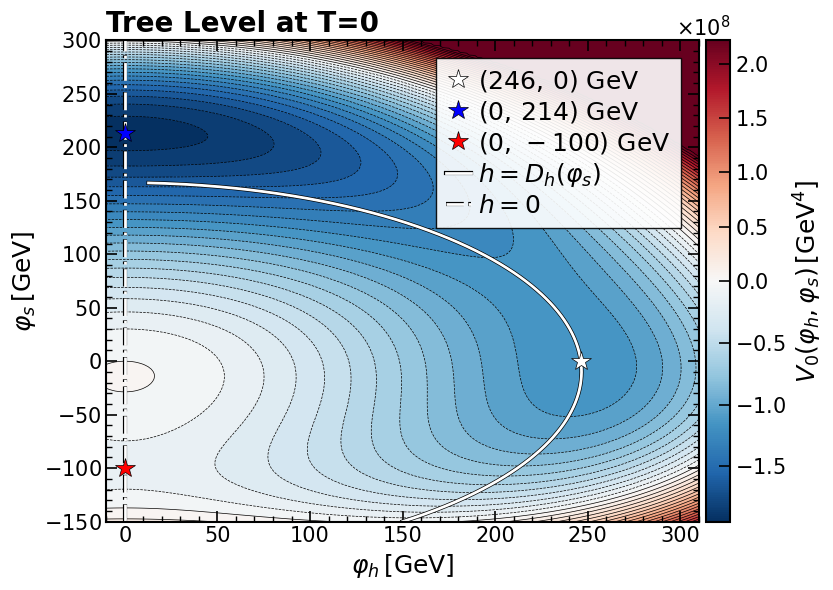

In [5]:
# Set the values of h & s 
hmin, hmax = (-10, 310)
smin, smax = (-150, 300)

# Create the Paths 
s_path  = np.linspace(smin, smax, 1000)
h_zeros = np.zeros_like(s_path)
h_plus  = np.full_like(s_path, np.nan)
h_minus = np.full_like(s_path, np.nan)

radicand = -s_path**2 * lHS + 2*muH2 - 2*s_path*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

# Potential Grid 
h_vals = np.linspace(hmin, hmax, 200)
s_vals = np.linspace(smin, smax, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 95))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

# Normalize the cmap
norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

# Create the Figure
fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[0], validX[0], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[0]:.0f},\,{validX[0]:.0f})$ GeV')
ax.plot(0, minima_roots[0], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[0]:.0f})$ GeV')
ax.plot(0, minima_roots[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[1]:.0f})$ GeV')
ax.plot(h_plus, s_path, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_zeros, s_path, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

# Make it Pretty
ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Unstable_TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

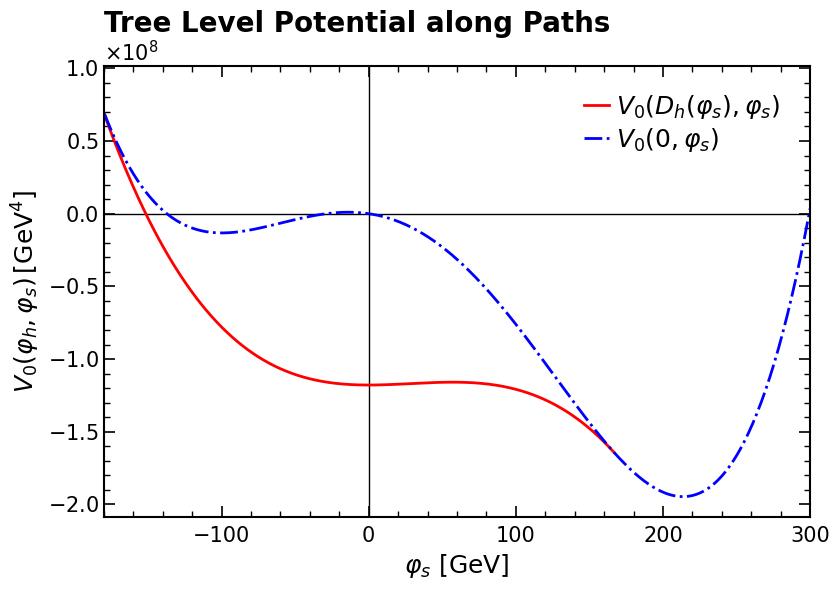

In [6]:
# Potential allong paths
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)
SPath0 = np.linspace(sm,smax,500)

Vs0 = mu13*SPath0-0.5*muS2*SPath0**2-mu3/3*SPath0**3+lS/4*SPath0**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*((muH2*muHS)/(2*lH) + mu13)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath0, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(-180, 300)
#ax.set_ylim(-1e8, 0.3e8)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Unstable_TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Coleman weinberg

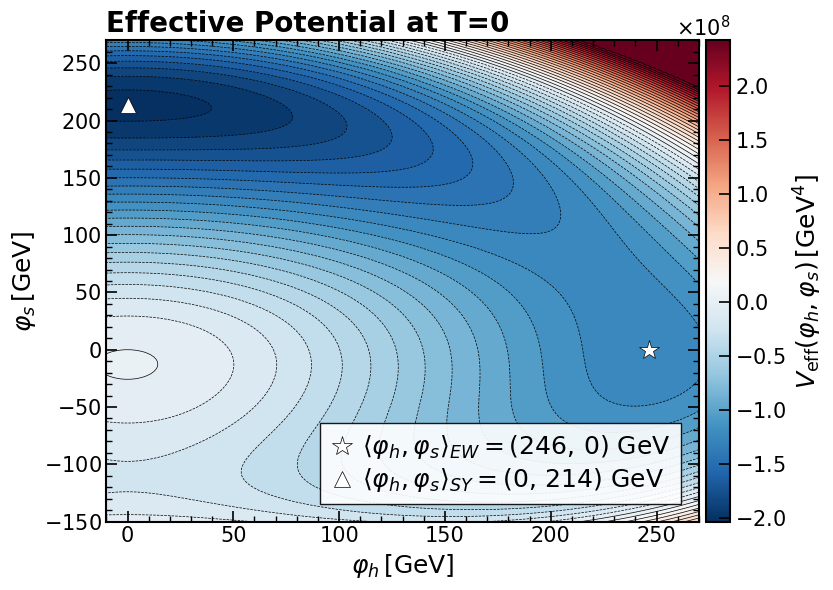

In [153]:
# Grid in (h, s)
h_vals = np.linspace(-10, 270, 200)
s_vals = np.linspace(-150, 270, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, 0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{EW}} = ({v:.0f},\,{0:.0f})$ GeV')
ax.plot(0, w, 'w^', markersize=11, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{SY}} = ({0:.0f},\,{w:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(r"Figures/Unstable_CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

### $\mathbb{Z}_2$ Symmetic Case

In [187]:
m1  = 125.20
m2  = 60
th  = 0
v0  = 246.22
lHS = 0.4
lS  = 0.2
mu3 = 0

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

lSmin = (lHS*v0**2-2*m2**2)**2/(2*v0**2*m1**2)

for i in params.keys():
    if i == "lS":
        print(f"{i} -> {params[i]}  lS min = {lSmin}")
    else:
        print(f"{i} -> {params[i]}")

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
v = model.v_os
w = model.w_os

muH2 -> 7837.52
lH -> 0.1292801978686813
mu13 -> -0.0
muHS -> 0.0
lHS -> 0.4
mu3 -> 0
lS -> 0.2  lS min = 0.15294981590072051
muS2 -> 8524.857680000001


#### Tree Level Potential

In [188]:
# --- Symmetric Extrema ---
coeffs = [lS,-mu3,-muS2, mu13]
roots = np.roots(coeffs)
real_roots = roots[np.abs(roots.imag) < 1e-8].real
d2V0 = -muS2 - 2.0 * mu3 * real_roots + 3.0 * lS * real_roots**2
minima_roots = real_roots[d2V0 > 0]

print("="*50)
print("    Symmetric Vaccua")
print("="*50)
print(f"The symmetric extrema are: {np.round(real_roots, 4)}")
print(f"The symmetric minima are: {np.round(minima_roots, 4)}")
print(f"The false vacuum is at s={w:.4f} GeV")
print()

# --- Non Symmetric Extrema ---
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

a = (lS - lHS**2/(4*lH))
b = -(mu3 + 3*lHS*muHS/(4*lH))
c = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH)
d = (muH2*muHS)/(2*lH) + mu13
X = np.roots([a, b, c, d])
realX = X[np.abs(X.imag) < 1e-8].real
validX = realX[(sm < realX) & (realX < sp)]
d2V = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH) - (mu3 + 3*lHS*muHS/(2*lH)) * validX + (lS - lHS**2/(4*lH)) * validX**2
minimaX = validX[d2V > 0]
root_hp  =  np.sqrt(-validX**2 * lHS + 2*muH2 - 2*validX*muHS) / (np.sqrt(2) * np.sqrt(lH))

print("="*50)
print("    Non-Symmetric Vaccua")
print("="*50)
print(f"The validity range of the Non-symmetric solutions is: [{sm:.4f},{sp:.4f}]")
print(f"The Non-Symmetric, valid, extrema are: {np.round(validX, 4)}, h-> {np.round(root_hp, 4)}")
print(f"The Non-Symmetric, valid, minima are: {np.round(minimaX, 4)}")
print()

print("="*50)
print("    Stability of the Potential")
print("="*50)
Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
print(f"V(v, 0) = {Vv[0]:.0f}")
print(f"V(0, w) = {Vw[0]:.0f}")

if Vv[0] < Vw[0]:
    print(f"The EW vaccum is stable")

if Vv[0] > Vw[0]:
    print(f"The EW vaccum is meta-stable")

    Symmetric Vaccua
The symmetric extrema are: [-206.4565  206.4565    0.    ]
The symmetric minima are: [-206.4565  206.4565]
The false vacuum is at s=-206.4565 GeV

    Non-Symmetric Vaccua
The validity range of the Non-symmetric solutions is: [-197.9586,197.9586]
The Non-Symmetric, valid, extrema are: [-181.3977  181.3977    0.    ], h-> [ 98.5858  98.5858 246.22  ]
The Non-Symmetric, valid, minima are: [-181.3977    0.    ]

    Stability of the Potential
V(v, 0) = -118786018
V(0, w) = -90841498
The EW vaccum is stable


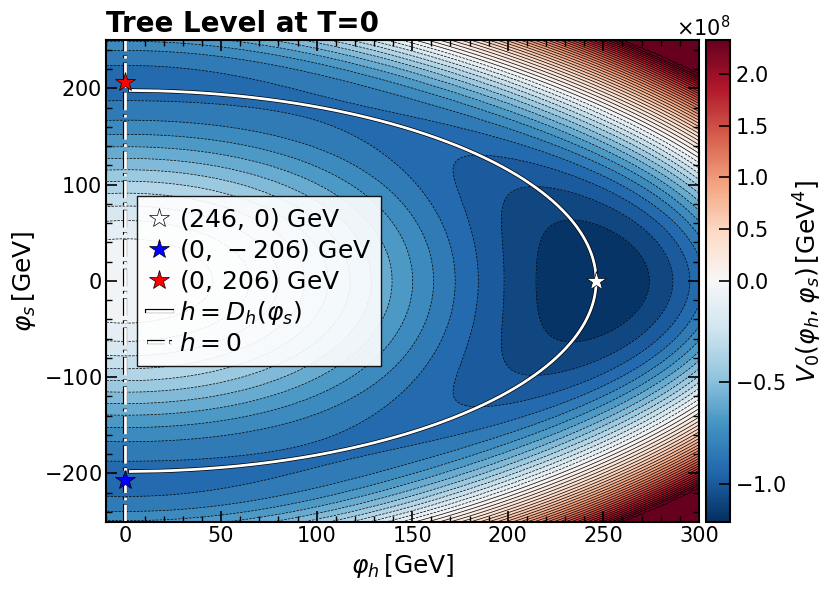

In [190]:
# Set the values of h & s 
hmin, hmax = (-10, 300)
smin, smax = (-250, 250)

# Create the Paths 
s_path  = np.linspace(smin, smax, 1000)
h_zeros = np.zeros_like(s_path)
h_plus  = np.full_like(s_path, np.nan)
h_minus = np.full_like(s_path, np.nan)

radicand = -s_path**2 * lHS + 2*muH2 - 2*s_path*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

# Potential Grid 
h_vals = np.linspace(hmin, hmax, 200)
s_vals = np.linspace(smin, smax, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

# Normalize the cmap
norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

# Create the Figure
fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[-1], validX[-1], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[-1]:.0f},\,{validX[-1]:.0f})$ GeV')
ax.plot(0, minima_roots[0], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[0]:.0f})$ GeV')
ax.plot(0, minima_roots[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[1]:.0f})$ GeV')
ax.plot(h_plus, s_path, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_zeros, s_path, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

# Make it Pretty
ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "center left", bbox_to_anchor=(0.03, 0.5),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

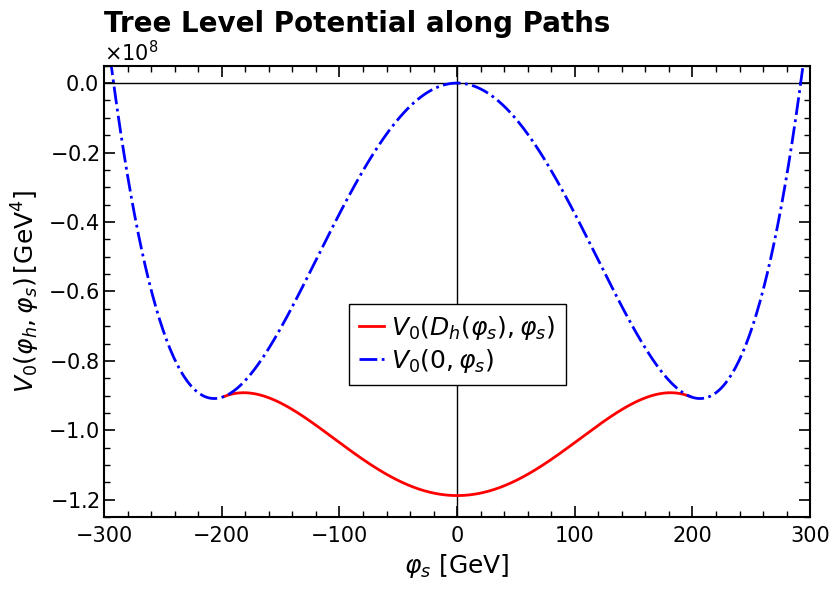

In [194]:
# Potential allong paths
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)
SPath0 = np.linspace(smin-500,smax+500,1000)

Vs0 = mu13*SPath0-0.5*muS2*SPath0**2-mu3/3*SPath0**3+lS/4*SPath0**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*((muH2*muHS)/(2*lH) + mu13)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath0, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(-300, 300)
ax.set_ylim(-1.25e8, 0.5e7)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper center", bbox_to_anchor=(0.5, 0.5),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Coleman Weinberg

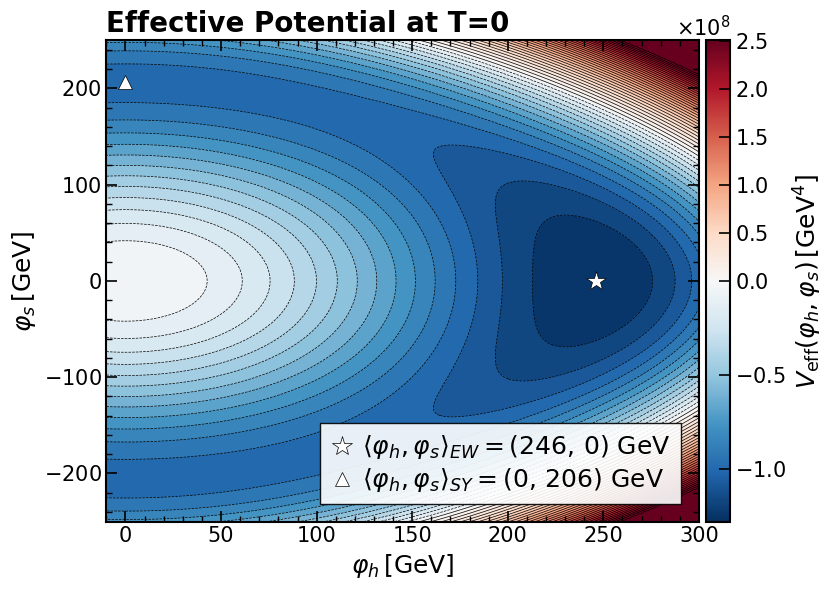

In [195]:
# Grid in (h, s)
h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-250, 250, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, 0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{EW}} = ({v:.0f},\,{0:.0f})$ GeV')
ax.plot(0, -w, 'w^', markersize=10, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{SY}} = ({0:.0f},\,{-w:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Phase Transitions

In [149]:
model.Tmax = 250

In [150]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [ 2.46220000e+02 -7.23369402e-08] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
................................................................................................................................................................
Tracing phase starting at x = [-5.86980235e-07  1.60587342e+02] ; t = 133.7781986211735
Tracing minimum down
traceMinimum t0 = 133.778
.......................................
Tracing minimum up
traceMinimum t0 = 133.778
.......................................
Tc = 131.7158 GeV  |  xi_c = 1.26


In [152]:
model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

Tunneling from phase 1 to phase 0 at T=128.4555
high_vev = [-2.58016381e-04  1.61581844e+02]
low_vev = [1.73041920e+02 1.02893646e-05]
Path deformation converged. 42 steps. fRatio = 1.74633e-02
Path deformation converged. 17 steps. fRatio = 1.68819e-02
Path deformation converged. 1 steps. fRatio = 8.76305e-02
Tunneling from phase 1 to phase 0 at T=128.456
high_vev = [8.42750351e-05 1.61581757e+02]
low_vev = [1.73040835e+02 1.68765249e-05]
Path deformation converged. 42 steps. fRatio = 1.74610e-02
Path deformation converged. 17 steps. fRatio = 1.70071e-02
Path deformation converged. 1 steps. fRatio = 8.79465e-02
Tunneling from phase 1 to phase 0 at T=130.9919
high_vev = [-6.60276680e-05  1.61122153e+02]
low_vev = [1.67331243e+02 1.38095844e-05]
Path deformation converged. 43 steps. fRatio = 1.87102e-02
Path deformation converged. 15 steps. fRatio = 9.94617e-03
Path deformation converged. 5 steps. fRatio = 5.26184e-03
Path deformation converged. 1 steps. fRatio = 1.20194e-03
Tunneling fr

In [154]:
Trans = model.TnTrans[0]

Tc    = Trans['crit_trans']['Tcrit']
highc = Trans['crit_trans']['high_vev']
lowc  = Trans['crit_trans']['low_vev']
xic   = abs(lowc[0] - highc[0]) / Tc
Tn    = Trans['Tnuc']
highn = Trans['high_vev']
lown  = Trans['low_vev']
xin   = abs(lown[0] - highn[0]) / Tc

print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tc = 131.7158 GeV  |  xi_c = 1.26


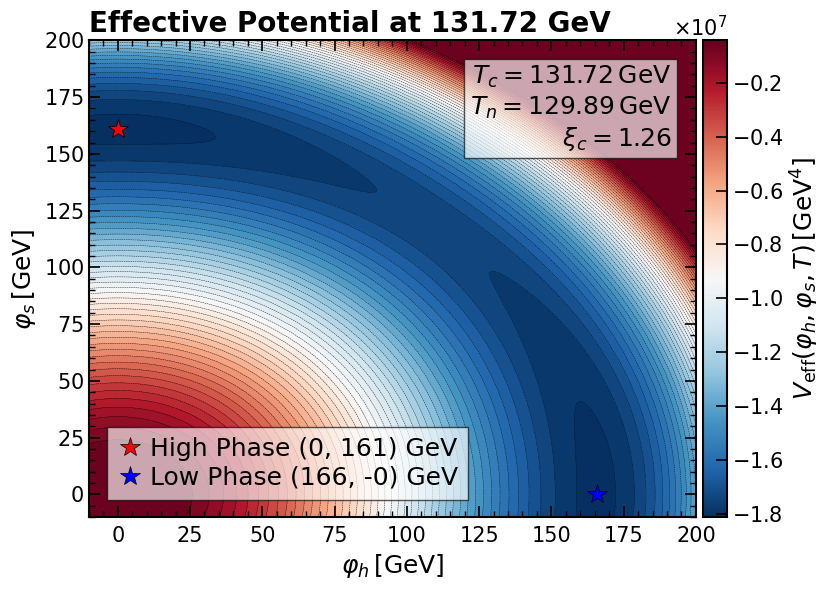

In [162]:
# Grid in (h, s)
h_vals = np.linspace(-10, 200, 200)
s_vals = np.linspace(-10, 200, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 90))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), Tc)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.plot(high[0], high[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'High Phase ({-high[0]:.0f}, {high[1]:.0f}) GeV')
ax.plot(low[0], low[1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'Low Phase ({low[0]:.0f}, {low[1]:.0f}) GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01), 
          ncol = 1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = (rf"$T_c   = {Tc:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$T_n = {Tn:.2f}\, \mathrm{{GeV}}$"
              "\n"rf"$\xi_c = {xi_c:.2f}$")
ax.text(0.96, 0.95, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='right',
       bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

plt.title(rf"Effective Potential at {Tc:.2f} GeV", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_Tc_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Preliminary Parameter Scans

### Single Point Test

In [5]:
def scan_point (Params):
    """
    Scans a point in the parameter space in search of a FOPT
    -> If succesfull retuns PT info
    -> If failed returns reason of failure (Unstable potential or No PT)

    Parameters
    ----------
    params : List of parameters [m1, m2, th, v0, lHS, lS, mu3]

        m1  : Mass of the Heavy Scalar (Assume 125 Higgs)
        m2  : Mass of the Light Scalar (Assume m2 < m1/2)
        th  : Mixing angle (Assume small -> H signal strength)
        v0  : EW vacuum from GF
        lHS : Portal Quartic Coupling (Constaints from H decays)
        lS  : Singlet Quartic Coupling (4pi > lS > Radiative Floor)
        mu3 : Singlet Qubic Coupling (m3 > Radiative Floor)

    Returns
    -------
    If succesful:
        [Xi_c, Tc]

    else
        ['Scan Failed', Reason]
    """
    m1, m2, th, v0, lHS, lS, mu3 = Params

    lSmin  = (lHS*v0**2-2*m2**2)**2/(2*v0**2*m1**2)
    lHSmin = (2*m2**2/v0**2)

    print(f"lS > {lSmin:.8f}")
    print(f"lHS > {lHSmin:.8f}")

    # Convert to Lagrangian Parameters
    LParams = physical_to_lagrangian(
        m1    = m1,
        m2    = m2,
        theta = th,
        v     = v0,
        lHS   = lHS,
        lS    = lS,
        mu3   = mu3)
    
    # Load the Model
    model = xSM(**{k: LParams[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
    v = model.v_os
    w = model.w_os

    # Check Potential Stability
    Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
    Vw = model.Vtot(np.array([[0.0, w]]), 0.0)

    if Vv[0] >= Vw[0]:
        return ['Scan Failed', 'Potential is Meta-Stable']
    
    # Look for a Phase Transition
    model.Tmax = 250
    trans = model.calcTcTrans()
    # No Transitions?
    if len(trans)==0:
        return ['Scan Failed', 'No Transitions']
    
    Tc   = trans[0]['Tcrit']
    high = trans[0]['high_vev']
    low  = trans[0]['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    
    return [xi_c, Tc]
    

In [6]:
params = [
    125.20, # m1
    60.0,   # m2
    0.0,    # theta
    246.22, # v
    2e-1,    # lHS
    8e-2,   # lS
    0.0     # mu3
]

Result = scan_point(params)
print(Result)

lS > 0.01276151
lHS > 0.11876428
Tracing phase starting at x = [ 2.46220000e+02 -7.23369402e-08] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
................................................................................................................................................................
Tracing phase starting at x = [6.54091164e-06 1.60587348e+02] ; t = 133.7781986211735
Tracing minimum down
traceMinimum t0 = 133.778
........................................
Tracing minimum up
traceMinimum t0 = 133.778
.......................................
[np.float64(1.25741077666328), 131.7158485073729]


### $Z_2$ Parameter Scan

In [69]:
FIXED = dict(m1=125.20, th=0.0, v0=246.22, mu3=0.0)

def build_grid_Z2(n_m2=6, n_lHS=6, n_lS=6, floor=1e-8):
    m2_vals  = np.linspace(10, 60, n_m2)
    lHS_vals = np.geomspace(1e-5, 1, n_lHS)

    points = []
    for m2 in m2_vals:
        for lHS in lHS_vals:
            lSmin = (lHS*FIXED['v0']**2 - 2*m2**2)**2 / (2*FIXED['v0']**2*FIXED['m1']**2)
            lSmin = max(lSmin, floor) # If lSmin is to small set it to floor

            if lSmin >= 1:
                continue # Skip this

            lS_vals = np.geomspace(lSmin, 1, n_lS)
            for lS in lS_vals:
                points.append((m2, lHS, lS))

    return points

In [134]:
def scan_point_Z2(params):
    m2, lHS, lS = params
    m1, th, v0, mu3 = FIXED['m1'], FIXED['th'], FIXED['v0'], FIXED['mu3']

    result = {
        'm1': m1, 'm2': m2, 'th': th, 'v0': v0, 'lHS': lHS, 'lS': lS, 'mu3': mu3,
        'Tc': np.nan, 'xi_c': np.nan,
        'status': 'unknown', 'error_msg': ''
    }

    try:
        LParams = physical_to_lagrangian(m1=m1, m2=m2, theta=th, v=v0, lHS=lHS, lS=lS, mu3=mu3)
        model = xSM(**{k: LParams[k] for k in ['lH','lHS','muHS','lS','mu3','muS2']})
        v, w = model.v_os, model.w_os

        Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
        Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
        if Vv[0] >= Vw[0]:
            result['status'] = 'meta_stable'
            return result

        model.Tmax = 250
        trans = model.calcTcTrans()
        if len(trans) == 0:
            result['status'] = 'no_transition'
            return result

        Tc   = trans[0]['Tcrit']
        high = trans[0]['high_vev']
        low  = trans[0]['low_vev']
        result['Tc']     = Tc
        result['xi_c']   = abs(low[0] - high[0]) / Tc
        result['status'] = 'success'
        return result

    except Exception as e:
        result['status']    = 'error'
        result['error_msg'] = f"{type(e).__name__}: {e}"
        return result

In [135]:
def run_scan(points, output_csv='Z2_scan.csv', n_workers=-1, checkpoint_every=50):
    if os.path.exists(output_csv):
        existing = pd.read_csv(output_csv)
        done = set(zip(existing['m2'].round(8), existing['lHS'].round(8), existing['lS'].round(8)))
        before = len(points)
        points = [p for p in points if (round(p[0],8), round(p[1],8), round(p[2],8)) not in done]
        print(f"Resuming: {before - len(points)} points already done, {len(points)} remaining.")

    write_header = not os.path.exists(output_csv)
    buffer = []

    parallel = Parallel(n_jobs=n_workers, return_as="generator")
    results_gen = parallel(delayed(scan_point_Z2)(p) for p in points)

    for res in tqdm(results_gen, total=len(points)):
        buffer.append(res)
        if len(buffer) >= checkpoint_every:
            pd.DataFrame(buffer).to_csv(output_csv, mode='a', header=write_header, index=False)
            write_header = False
            buffer = []

    if buffer:
        pd.DataFrame(buffer).to_csv(output_csv, mode='a', header=write_header, index=False)

    return pd.read_csv(output_csv)

In [136]:
points = build_grid_Z2(n_m2=20, n_lHS=5, n_lS=5)
df = run_scan(points, output_csv='Z2_Scan.csv', checkpoint_every=100)
df['status'].value_counts()

Resuming: 40 points already done, 360 remaining.


  0%|          | 0/360 [00:00<?, ?it/s]

Tracing phase starting at x = [ 2.46220000e+02 -4.26073632e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
Tracing phase starting at x = [ 2.46219998e+02 -5.16285165e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
.Tracing phase starting at x = [ 2.46219999e+02 -6.64685370e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..Tracing phase starting at x =. [ 2.46220000e+02 -3.51373973e-07] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
........Tracing phase starting at x = [ 2.46220000e+02 -4.26073632e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..................Tracing phase starting at x = [ 2.46220000e+02 -4.26073632e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
....................................................................................................................................................................................................................................................................................................

status
success          16925
no_transition      336
meta_stable        288
error              195
Name: count, dtype: int64

## Parameter Scan

### Single Point Test

## Read the Data

In [165]:
Data = pd.read_csv('Z2_Scan.csv')

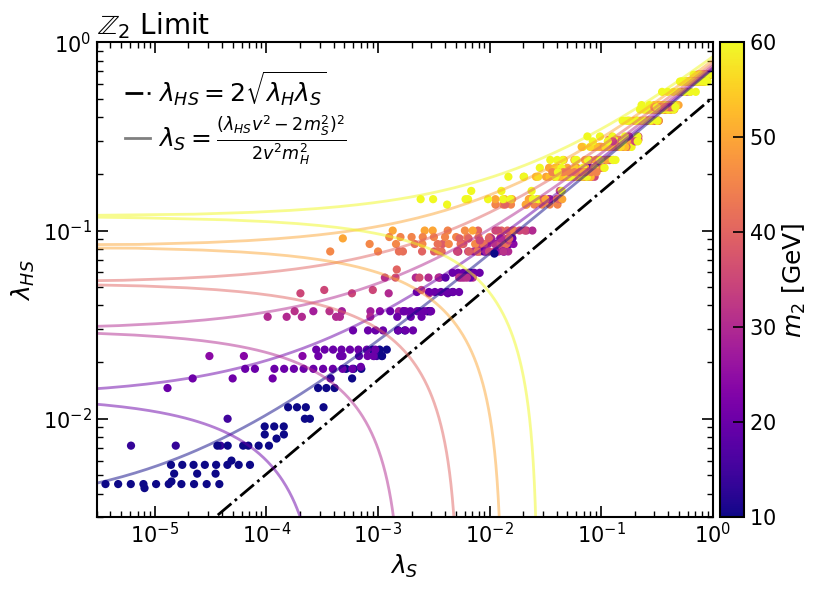

In [87]:
df = Data[(Data.xi_c > 1)]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(2*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"$\mathbb{Z}_2$ Limit", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_lS-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


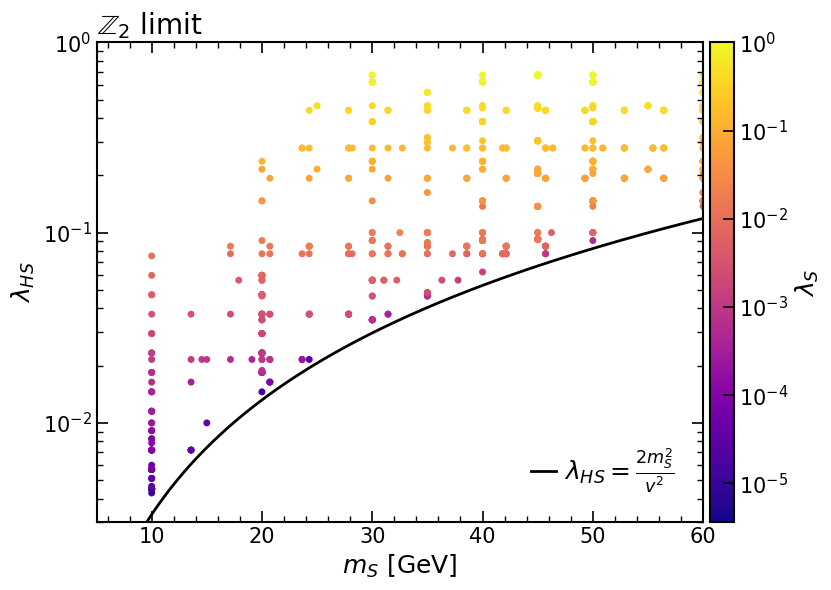

In [85]:
# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/FIXED['v0']**2

df = Data[(Data.xi_c > 1)]

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, 60)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"$\mathbb{Z}_2$ limit", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Nucleation Test

In [3]:
Data = pd.read_csv('Z2_Scan.csv')

In [4]:
Data[(Data.xi_c>1)&(Data.m2>59)&(Data.lHS>4e-1)&(Data.lHS<5e-1)]

,m1,m2,th,v0,lHS,lS,mu3,Tc,xi_c,status,error_msg
4860,125.2,60.0,0.0,246.22,0.439397,0.223119,0.0,59.784528,4.037469,success,NaN
4861,125.2,60.0,0.0,246.22,0.439397,0.250408,0.0,74.109437,3.177344,success,NaN
4862,125.2,60.0,0.0,246.22,0.439397,0.281036,0.0,84.148723,2.724833,success,NaN
4863,125.2,60.0,0.0,246.22,0.439397,0.315409,0.0,92.026469,2.423523,success,NaN
4864,125.2,60.0,0.0,246.22,0.439397,0.353987,0.0,98.526641,2.200176,success,NaN
4865,125.2,60.0,0.0,246.22,0.439397,0.397282,0.0,104.051945,2.023802,success,NaN
4866,125.2,60.0,0.0,246.22,0.439397,0.445874,0.0,108.840899,1.878644,success,NaN
6284,125.2,60.0,0.0,246.22,0.464159,0.230695,0.0,9.267480,26.567737,success,NaN
6285,125.2,60.0,0.0,246.22,0.464159,0.271527,0.0,66.472723,3.595165,success,NaN
6287,125.2,60.0,0.0,246.22,0.464159,0.376149,0.0,93.709000,2.362958,success,NaN


In [10]:
params = [
    125.20, # m1
    60.0,   # m2
    0.0,    # theta
    246.22, # v
    0.4,    # lHS
    0.36,   # lS
    0.0     # mu3
]

Result = scan_point(params)
print(Result)

lS > 0.15294982
lHS > 0.11876428
Tracing phase starting at x = [ 2.46219999e+02 -1.45744550e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
............................................................................................................
Tracing phase starting at x = [5.10104126e-06 1.47112251e+02] ; t = 112.00160517412078
Tracing minimum down
traceMinimum t0 = 112.002
...............................................
Tracing minimum up
traceMinimum t0 = 112.002
..........................................
[np.float64(1.831842675703672), 110.50225491856932]


In [9]:
m1  = 125.20
m2  = 60
th  = 0
v0  = 246.22
lHS = 0.4
lS  = 0.36
mu3 = 0

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
model.Tmax = 250
model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

Trans = model.TnTrans[0]

Tc    = Trans['crit_trans']['Tcrit']
highc = Trans['crit_trans']['high_vev']
lowc  = Trans['crit_trans']['low_vev']
xic   = abs(lowc[0] - highc[0]) / Tc
Tn    = Trans['Tnuc']
highn = Trans['high_vev']
lown  = Trans['low_vev']
xin   = abs(lown[0] - highn[0]) / Tc

print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xic:.2f}")

Tracing phase starting at x = [ 2.46219999e+02 -1.45744550e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
............................................................................................................
Tracing phase starting at x = [-7.01676974e-06  1.47112250e+02] ; t = 112.00160517412078
Tracing minimum down
traceMinimum t0 = 112.002
......................................................
Tracing minimum up
traceMinimum t0 = 112.002
..........................................
Tunneling from phase 1 to phase 0 at T=107.9741
high_vev = [3.86621340e-05 1.47626604e+02]
low_vev = [ 2.05882176e+02 -1.16613826e-05]
Path deformation converged. 45 steps. fRatio = 1.98133e-02
Path deformation converged. 13 steps. fRatio = 1.79950e-02
Path deformation converged. 1 steps. fRatio = 3.37109e-03
Tunneling from phase 1 to phase 0 at T=107.9746
high_vev = [1.07624253e-04 1.47626544e+02]
low_vev = [ 2.05881512e+02 -7.22132066e-06]
Path deformation converged. 45 steps. fRatio = 1.9813